# U-Net 구현

> **논문**: U-Net: Convolutional Networks for Biomedical Image Segmentation (Ronneberger et al., MICCAI 2015)


```
주요 흐름

1. 환경 준비  →  2. 데이터 준비  →  3. 모델링1 (블록 단위)  →  4. 모델링2 (전체 U-Net)  →  5. 학습 & 평가
```


### 사용한 데이터셋
**Oxford-IIIT Pet Dataset** — 반려동물 사진 + 픽셀 단위 마스크 (배경 / 동물 / 윤곽선 3가지 클래스)

---
## 1. 환경 준비

### (1) 라이브러리 Import



In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 55.7 MB/s eta 0:00:00


In [2]:
# ===== 라이브러리 불러오기 =====
# 파일 시스템 및 유틸리티
import os           # 운영체제 파일 경로 처리
import glob         # 와일드카드 패턴으로 파일 목록 가져오기
import numpy as np  # 수치 연산 라이브러리 (배열 처리)
import random       # 랜덤 숫자 생성 (데이터 증강에서 확률 판단용)
from tqdm import tqdm  # 루프 진행률 표시 바

# PyTorch 기본 라이브러리
import torch                        # PyTorch 핵심 라이브러리
import torch.nn as nn               # 신경망 레이어 모듈 (Conv2d, BatchNorm 등)

from torch.utils.data import DataLoader, Dataset  # 데이터셋/로더 추상 클래스

# torchvision: 데이터셋 및 이미지 변환
from torch.utils.data.dataset import random_split  # 데이터셋 분할 함수
import torchvision.transforms as T                  # 이미지 전처리 변환 모음
from torchvision.transforms import InterpolationMode  # 보간법 설정 (마스크 리사이즈 시 NEAREST 사용)

# 이미지 처리
from PIL import Image  # PIL: Python Imaging Library (이미지 열기/저장)

# 시각화 라이브러리
import matplotlib.pyplot as plt  # 그래프/이미지 시각화
import koreanize_matplotlib

from torchsummary import summary  # 모델 구조 및 파라미터 수 요약 출력

### (2) 필요 함수 생성

#### 학습 함수 (train)

- 입력 이미지: `(N, 3, H, W)`
- 모델 출력: `(N, num_classes, H, W)` — 픽셀별 예측값
- 마스크(정답): `(N, H, W)` — 정수 클래스

In [2]:
# ===== 학습 함수 (train) =====
# 한 에폭(epoch) 동안 전체 학습 데이터를 한 번 순회하며 모델 파라미터를 업데이트한다.
# 흐름: 배치 꺼내기 → GPU로 이동 → 예측 → 손실 계산 → 역전파 → 파라미터 업데이트

def train(dataloader, model, loss_fn, optimizer, device):
    model.train()   # 학습 모드 활성화: Dropout, BatchNorm이 학습 동작으로 전환됨
    total_loss = 0.0  # 에폭 전체 손실 합계 누적용 변수

    for images, masks in dataloader:
        # DataLoader가 batch_size 단위로 (이미지, 마스크) 쌍을 꺼내줌
        # 픽셀 하나씩 for 루프 돌리지 않아도 됨 — GPU가 (N, H, W) 전체를 병렬로 처리함

        # 데이터를 GPU(또는 CPU)로 이동
        images = images.to(device)                      # (N, 3, H, W) — N장의 RGB 이미지
        masks = masks.to(device).squeeze(1).long()
        # squeeze(1): 마스크가 (N, 1, H, W) 형태라면 채널 차원 제거 → (N, H, W)
        # .long(): CrossEntropyLoss는 정답 레이블을 정수(class 번호)로 받아야 함
        #           float이면 오류 발생. 픽셀마다 클래스 번호(0,1,2 등)를 나타냄

        # ── 순전파(Forward Pass) ──
        pred = model(images)
        # 출력 shape: (N, num_classes, H, W)
        # 픽셀 하나당 클래스 수만큼 점수(로짓)가 나옴
        # 예) 클래스 3개 → 픽셀 하나당 [0.1, 0.8, 0.1] 같은 점수 벡터

        # ── 손실 계산(Loss) ──
        loss = loss_fn(pred, masks)
        # CrossEntropyLoss: pred(N, C, H, W)와 masks(N, H, W)를 받아
        # 픽셀별로 예측값과 정답 클래스 번호를 비교해 손실 계산

        # ── 역전파(Backward Pass) & 파라미터 업데이트 ──
        optimizer.zero_grad()  # 이전 배치의 기울기 초기화 (누적 방지 — 맨 먼저 호출!)
        loss.backward()        # 손실에 대한 각 파라미터의 기울기 계산 (미분)
        optimizer.step()       # 기울기 방향으로 파라미터 업데이트 (경사 하강)

        total_loss += loss.item()  # 배치 손실값을 float으로 꺼내 누적

    avg_loss = total_loss / len(dataloader)  # 배치 수로 나눠 평균 손실 계산
    return avg_loss

	•	images shape: (N, 3, H, W)
	•	masks shape: (N, H, W)
	•	pred shape: (N, num_classes, H, W)

예측값은 채널축 포함,
정답은 클래스 인덱스만 있는 3차원 형태를 받는다. -> segmentation에서는 정답 마스크를 one-hot으로 안 바꾸고 그냥 넣는다.


#### IoU 계산 함수 + 평가 함수 (evaluate)

Segmentation의 성능 지표는 **IoU (Intersection over Union)**

$$\text{IoU} = \frac{\text{예측 영역} \cap \text{실제 영역}}{\text{예측 영역} \cup \text{실제 영역}}$$



단순 픽셀 정확도(accuracy)는 함정이 있음.

배경이 95%, 객체가 5%인 이미지에서 전부 배경으로 예측해도 accuracy 95%. 하지만 객체를 하나도 못 찾은 것임

그래서 세그멘테이션에서는 IoU를 씀. IoU = 교집합 / 합집합
    = 둘 다 c인 픽셀 / 하나라도 c인 픽셀

클래스가 3개(배경/고양이/개)면, 각각 따로 측정해서 평균냄.(전체를 한번에 비교하면 클래스 불균형에 또 속음. 클래스별로 따로 재야 공정함.)

In [3]:
# ===== IoU 계산 함수 & 평가 함수 (evaluate) =====

# --- compute_iou: 클래스별 IoU를 계산하고 평균을 반환 ---
# IoU = 교집합(둘 다 c인 픽셀) / 합집합(하나라도 c인 픽셀)
# 단순 정확도(accuracy)는 클래스 불균형 시 왜곡되므로, segmentation에서는 IoU를 사용
def compute_iou(pred, target, num_classes=3):
    iou_list = []

    for c in range(num_classes):
        # 픽셀 하나하나 for 루프 안 돌림. 클래스별로 마스크 비교 후 한번에 처리
        # (pred == c): (N, H, W) 전체 픽셀을 동시에 비교 → True/False 텐서 반환

        pred_c   = (pred == c)    # 모델이 클래스 c라고 예측한 픽셀 위치 (True/False)
        target_c = (target == c)  # 실제 정답이 클래스 c인 픽셀 위치 (True/False)

        intersection = (pred_c & target_c).sum().item()  # 예측과 정답이 모두 c인 픽셀 수
        union        = (pred_c | target_c).sum().item()  # 예측 또는 정답이 c인 픽셀 수

        if union == 0:
            # 해당 클래스가 예측/정답 모두 없는 경우 → 완벽히 맞춘 것으로 처리
            iou = 1.0
        else:
            iou = intersection / union  # IoU 계산

        iou_list.append(iou)

    # 전체 클래스의 IoU 평균 반환 (mIoU)
    return sum(iou_list) / len(iou_list)


# --- evaluate: 검증/테스트 데이터로 손실과 mIoU를 측정 ---
# train과 달리 역전파를 하지 않고 성능만 측정 (파라미터 변경 없음)
def evaluate(dataloader, model, loss_fn, device, num_classes=3):
    model.eval()       # 평가 모드: Dropout 비활성화, BatchNorm 추론 모드로 전환
    total_loss = 0     # 전체 손실 누적 초기화
    total_iou  = 0     # 전체 IoU 누적 초기화

    with torch.no_grad():
        # torch.no_grad(): 기울기 추적을 끔 → 메모리 절약 + 연산 속도 향상
        # 평가 단계에서는 역전파가 필요 없으므로 기울기 계산 불필요

        for images, masks in dataloader:
            images = images.to(device)
            masks  = masks.to(device).squeeze(1).long()  # (N, 1, H, W) → (N, H, W), 정수형

            # 순전파: 픽셀별 클래스 점수(로짓) 출력
            pred = model(images)  # (N, num_classes, H, W)

            # 손실 계산
            loss = loss_fn(pred, masks)
            total_loss += loss.item()

            # argmax: 채널(클래스) 차원에서 가장 높은 점수의 클래스 인덱스를 선택
            pred_class = torch.argmax(pred, dim=1)  # (N, H, W) — 픽셀별 예측 클래스 번호

            # IoU 계산 (배치 단위 평균)
            iou = compute_iou(pred_class, masks, num_classes)
            total_iou += iou

    avg_loss = total_loss / len(dataloader)  # 배치 평균 손실
    avg_iou  = total_iou  / len(dataloader)  # 배치 평균 IoU
    return avg_loss, avg_iou

#### 학습 곡선 + 결과 시각화 함수



In [7]:
# ===== 시각화 함수들 =====

# --- dl_learning_curve: 학습/검증 손실과 IoU 변화를 그래프로 출력 ---
def dl_learning_curve(tr_loss_list, val_loss_list, val_iou_list):
    epochs = range(1, len(tr_loss_list) + 1)  # x축: 에폭 번호 (1부터 시작)

    plt.plot(epochs, tr_loss_list,  label='train_loss')  # 학습 손실 곡선
    plt.plot(epochs, val_loss_list, label='val_loss')    # 검증 손실 곡선
    plt.plot(epochs, val_iou_list,  label='val_IoU')     # 검증 IoU 곡선

    plt.xlabel('Epoch')   # x축 레이블
    plt.ylabel('Value')   # y축 레이블
    plt.title('Learning Curve')  # 그래프 제목
    plt.legend()          # 범례 표시
    plt.grid(True)        # 격자 표시
    plt.show()


# --- visualize_prediction: 원본 이미지 | 정답 마스크 | 예측 마스크를 나란히 시각화 ---
def visualize_prediction(image, true_mask, pred_mask, title=""):
    """
    Args:
        image     : (3, H, W) 텐서 또는 (H, W, 3) numpy 배열 — 원본 이미지
        true_mask : (H, W) 정수 마스크 — 정답 레이블
        pred_mask : (H, W) 정수 마스크 — 모델 예측 레이블
        title     : 그래프 상단에 표시할 제목 (선택)
    """
    # Tensor → NumPy 변환 (matplotlib은 NumPy 배열을 입력으로 받음)
    if isinstance(image, torch.Tensor):
        image = image.cpu().numpy()
        image = np.transpose(image, (1, 2, 0))  # (C, H, W) → (H, W, C) 형태로 변환

    if isinstance(true_mask, torch.Tensor):
        true_mask = true_mask.cpu().numpy()

    # 1행 3열 서브플롯 생성
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # 왼쪽: 원본 이미지
    axes[0].imshow(image)
    axes[0].set_title("Image")
    axes[0].axis("off")  # 축 눈금 숨기기

    # 가운데: 정답 마스크 (jet 컬러맵: 클래스별 색상 구분)
    axes[1].imshow(true_mask, cmap="jet")
    axes[1].set_title("Ground Truth")
    axes[1].axis("off")

    # 오른쪽: 예측 마스크
    axes[2].imshow(pred_mask, cmap="jet")
    axes[2].set_title("Prediction")
    axes[2].axis("off")

    if title != "":
        fig.suptitle(title)  # 전체 그림 제목 설정

    plt.show()

### (3) Device 준비

In [3]:
# ===== 학습 장치(Device) 설정 =====
# CUDA(GPU)가 사용 가능하면 GPU를 사용하고, 아니면 CPU를 사용
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch 버전:", torch.__version__)
print("CUDA 사용 가능 여부:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("CUDA 버전:", torch.version.cuda)

PyTorch 버전: 2.10.0+cu128
CUDA 사용 가능 여부: True
CUDA 버전: 12.8


### (4) 데이터셋 다운로드

- 이미지와 마스크를 **동일한 크기** (예: 128×128)로 변환.
- 마스크는 `InterpolationMode.NEAREST` 보간법을 사용 (클래스 번호가 왜곡되지 않도록).

In [4]:
# ===== 데이터셋 다운로드 및 전처리 변환 정의 =====
# Oxford-IIIT Pet Dataset: 반려동물 이미지 + 픽셀 단위 segmentation 마스크
# 마스크 클래스: 1=배경, 2=동물, 3=윤곽선 → -1 처리로 0,1,2로 변환

from torchvision.datasets import OxfordIIITPet

# ── 이미지 전처리 변환 파이프라인 ──
image_transform = T.Compose([
    T.Resize((128, 128)),                              # 이미지를 128×128로 리사이즈
    T.ToTensor(),                                      # PIL 이미지 → [0,1] 범위 float 텐서로 변환
    T.Normalize(mean=[0.485, 0.456, 0.406],            # ImageNet 평균으로 정규화
                std=[0.229, 0.224, 0.225])             # ImageNet 표준편차로 정규화
])

# ── 마스크 전처리 변환 파이프라인 ──
mask_transform = T.Compose([
    T.Resize((128, 128), interpolation=T.InterpolationMode.NEAREST),
    # NEAREST: 가장 가까운 픽셀 값 사용 — 클래스 번호가 보간 과정에서 왜곡되지 않도록
    T.PILToTensor(),                                   # PIL 마스크 → 텐서 (값: 1, 2, 3)
    T.Lambda(lambda x: x.squeeze(0).long() - 1)
    # squeeze(0): (1, H, W) → (H, W) 채널 차원 제거
    # .long(): 정수형으로 변환 (CrossEntropyLoss 입력 요건)
    # -1: 원본 마스크 값 {1,2,3}을 {0,1,2}로 변환 (0-indexed 클래스 번호)
])

# ── 학습 데이터셋 ──
train_dataset = OxfordIIITPet(
    root="./data",                  # 데이터를 저장/불러올 루트 경로
    split="trainval",               # 학습+검증용 분할 사용
    target_types="segmentation",    # segmentation 마스크를 타겟으로 설정
    download=True,                  # 없으면 자동 다운로드
    transform=image_transform,      # 이미지 변환 적용
    target_transform=mask_transform # 마스크 변환 적용
)

# ── 테스트 데이터셋 ──
test_dataset = OxfordIIITPet(
    root="./data",
    split="test",                   # 테스트용 분할 사용
    target_types="segmentation",
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

100%|██████████| 792M/792M [00:39<00:00, 20.1MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 13.2MB/s]


In [5]:
# ===== 데이터 1건 꺼내서 shape 확인 =====
# 전처리가 제대로 적용됐는지 이미지/마스크 형태와 클래스 값 검증
image, mask = train_dataset[0]

print("이미지 shape:", image.shape)   # 기대값: torch.Size([3, 128, 128]) — (C, H, W)
print("마스크 shape:", mask.shape)    # 기대값: torch.Size([128, 128]) — (H, W)
print("마스크 고유값:", mask.unique()) # 기대값: tensor([0, 1, 2]) — 3개 클래스

이미지 shape: torch.Size([3, 128, 128])
마스크 shape: torch.Size([128, 128])
마스크 고유값: tensor([0, 1, 2])


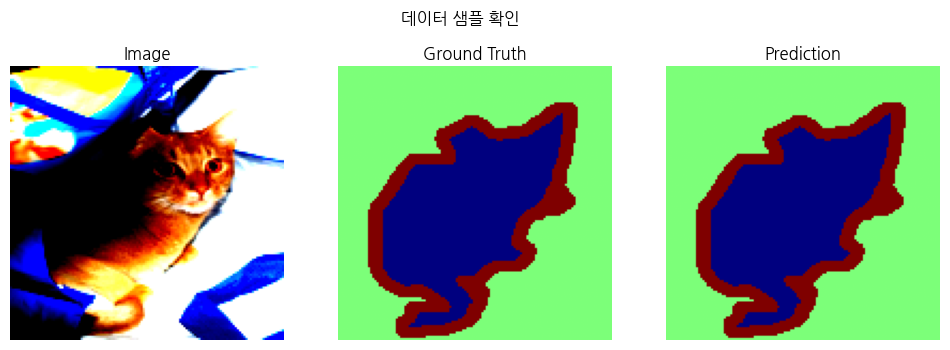

In [8]:
# ===== 데이터 샘플 시각화 =====
# 원본 이미지와 정답 마스크를 나란히 출력해 데이터 로딩 상태를 눈으로 확인
# (pred_mask 자리에 true_mask를 넣어서 정답만 두 번 표시)
visualize_prediction(image, mask, mask, title="데이터 샘플 확인")

---
## 2. 데이터 준비


U-Net 논문 원본은 `batch_size=1` 을 사용(논문 당시 GPU메모리 부족, 대신 Elastic Deformation 사용한 전략)했으나 본 구현파일에서는 8 선택함

In [9]:
# ===== DataLoader 생성 =====
# DataLoader: 데이터셋에서 batch_size 단위로 데이터를 꺼내주는 이터레이터
# U-Net 원논문은 batch_size=1 사용(GPU 메모리 한계), 여기서는 8 사용

batch_size = 8  # 한 번에 처리할 이미지 수

# 학습 DataLoader: shuffle=True — 매 에폭마다 데이터 순서를 섞어 과적합 방지
train_dataloader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True   # 매 에폭마다 순서를 섞음 (학습 안정성 향상)
)

# 첫 번째 배치 꺼내서 shape 확인
for imgs, masks in train_dataloader:
    print("이미지 배치 shape:", imgs.shape)   # 기대값: (8, 3, 128, 128)
    print("마스크 배치 shape:", masks.shape)  # 기대값: (8, 128, 128)
    break  # 첫 배치만 확인하고 중단

이미지 배치 shape: torch.Size([8, 3, 128, 128])
마스크 배치 shape: torch.Size([8, 128, 128])


In [10]:
# ===== 검증/테스트 데이터셋 분리 및 DataLoader 생성 =====
# 원본 test_dataset을 절반씩 나눠 val(검증)과 test(최종 평가)로 사용

val_size  = len(test_dataset) // 2           # 전체 테스트 수의 절반을 검증용으로
test_size = len(test_dataset) - val_size     # 나머지를 최종 테스트용으로

# random_split: 데이터셋을 지정한 크기로 무작위 분할
val_dataset, test_final_dataset = random_split(test_dataset, [val_size, test_size])

# 검증 DataLoader: shuffle=False — 평가 시에는 순서를 유지해야 결과 재현 가능
val_dataloader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False  # 평가이므로 순서 유지 (재현성 확보)
)

# 최종 테스트 DataLoader: 학습 종료 후 단 한 번 사용하는 데이터
test_dataloader = DataLoader(
    test_final_dataset,
    batch_size=batch_size,
    shuffle=False  # 평가이므로 순서 유지
)

In [11]:
# ===== 커스텀 데이터셋 클래스 (데이터 증강 포함) =====
# 기본 OxfordIIITPet 위에 데이터 증강(Augmentation)을 적용하는 커스텀 Dataset
# augment=True 시 학습 데이터에만 랜덤 뒤집기/회전 적용 → 과적합 방지
import torchvision.transforms.functional as F

class PetSegDataset(Dataset):
    def __init__(self, root="./data", split="trainval", augment=False):
        # OxfordIIITPet: 변환 없이 원본 PIL 이미지와 마스크를 반환하도록 설정
        self.dataset = OxfordIIITPet(
            root=root,
            split=split,
            target_types="segmentation",
            download=True
        )
        self.augment = augment  # True이면 증강 적용 (학습셋에서만 사용)

        # 이미지 전처리 파이프라인
        self.image_transform = T.Compose([
            T.Resize((128, 128)),                           # 128×128로 리사이즈
            T.ToTensor(),                                   # PIL → float 텐서 [0,1]
            T.Normalize(mean=[0.485, 0.456, 0.406],         # ImageNet 평균으로 정규화
                        std=[0.229, 0.224, 0.225])
        ])

        # 마스크 리사이즈 (NEAREST: 클래스 번호 보존)
        self.mask_resize    = T.Resize((128, 128), interpolation=T.InterpolationMode.NEAREST)
        # 마스크를 PIL → 텐서로 변환
        self.mask_to_tensor = T.PILToTensor()

    def __len__(self):
        # Dataset 총 샘플 수 반환 (DataLoader가 내부적으로 호출)
        return len(self.dataset)

    def __getitem__(self, idx):
        # idx번째 (원본 PIL 이미지, 원본 PIL 마스크) 쌍을 가져옴
        image, mask = self.dataset[idx]

        # ── 데이터 증강 (augment=True이고 학습셋에서만 적용) ──
        if self.augment:
            # 50% 확률로 좌우 뒤집기 (수평 반전)
            if random.random() > 0.5:
                image = F.hflip(image)
                mask  = F.hflip(mask)   # 이미지와 동일한 변환을 마스크에도 적용

            # 50% 확률로 상하 뒤집기 (수직 반전)
            if random.random() > 0.5:
                image = F.vflip(image)
                mask  = F.vflip(mask)

            # 50% 확률로 90도 회전
            if random.random() > 0.5:
                image = F.rotate(image, 90)
                mask  = F.rotate(mask, 90)

        # ── 이미지 전처리 ──
        image = F.resize(image, (128, 128))  # PIL 이미지 리사이즈 (증강 전 크기가 다를 수 있으므로)
        image = self.image_transform(image)  # Resize→ToTensor→Normalize 적용

        # ── 마스크 전처리 ──
        mask = self.mask_resize(mask)              # NEAREST 보간으로 128×128 리사이즈
        mask = self.mask_to_tensor(mask).squeeze(0).long() - 1
        # squeeze(0): (1, H, W) → (H, W) 채널 차원 제거
        # .long(): 정수형으로 변환
        # -1: 마스크 값 {1,2,3} → {0,1,2}로 변환

        # 혹시 (1, H, W) 형태가 남아있다면 한 번 더 제거
        mask = mask.squeeze(0).long()

        return image, mask

---
## 3. 모델링1 — U-Net 구성 블록



### (1) DoubleConv 블록

- 간단한 구현을 위해 `padding=1` 로 이미지 크기 유지함

In [12]:
# ===== U-Net 기본 블록: DoubleConv =====
# U-Net의 모든 단계에서 반복 사용되는 핵심 빌딩 블록
# 구조: (Conv2d(3×3) → BatchNorm → ReLU) × 2
# padding=1 → 출력 feature map 크기를 입력과 동일하게 유지

class DoubleConv(nn.Module):
    """
    U-Net 기본 블록: (Conv2d → BatchNorm → ReLU) × 2
    in_channels  : 입력 채널 수
    out_channels : 출력 채널 수
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            # 첫 번째 Conv: in_channels → out_channels, 3×3 커널, padding=1로 크기 유지
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),  # 배치 정규화: 학습 안정화, 빠른 수렴
            nn.ReLU(inplace=True),         # 비선형 활성화 (inplace=True: 메모리 절약)

            # 두 번째 Conv: out_channels → out_channels (채널 수 유지)
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        # x: (N, in_channels, H, W) → 출력: (N, out_channels, H, W) — 공간 크기 동일
        return self.conv(x)

### (2) Down 블록 (Encoder)

```
입력 → MaxPool2d(2×2) → DoubleConv → 출력
```
- 해상도 절반으로 줄어듦 (128 → 64 → 32 → 16)
- 채널 수 2배로 늘어남 (64 → 128 → 256 → 512)

In [13]:
# ===== Encoder 블록: Down =====
# U-Net 인코더(수축 경로)의 한 단계
# 구조: MaxPool2d(2×2) → DoubleConv
# - MaxPool: 공간 해상도를 절반으로 줄여 넓은 문맥 정보 획득
# - DoubleConv: 채널 수를 2배로 늘려 더 복잡한 특징 표현
# 예: (64, 128×128) → (128, 64×64)

class Down(nn.Module):
    """
    Encoder 블록: MaxPool2d → DoubleConv
    해상도: H×W → H/2 × W/2 (절반)
    채널 수: in_channels → out_channels (보통 2배)
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.pool_conv = nn.Sequential(
            nn.MaxPool2d(2),                          # 2×2 최댓값 풀링: 해상도 절반 축소
            DoubleConv(in_channels, out_channels)     # 채널 수 증가 + 특징 추출
        )

    def forward(self, x):
        # x: (N, in_channels, H, W) → 출력: (N, out_channels, H/2, W/2)
        return self.pool_conv(x)

### (3) Up 블록 (Decoder + Skip Connection)


```
Encoder의 특징맵 (skip) ────────────────┐
                                        │ torch.cat([x2, x1], dim=1)
Decoder 출력 → Upsample(2배) ───────────┘
                                        ↓
                                   DoubleConv → 출력
```

`forward(self, x1, x2)`: x1은 아래에서 올라오는 경로, x2는 skip connection


In [14]:
# ===== Decoder 블록: Up (Skip Connection 포함) =====
# U-Net 디코더(확장 경로)의 한 단계
# 구조: ConvTranspose2d(업샘플링) → Skip Connection Concat → DoubleConv
# - ConvTranspose2d: 해상도를 2배로 복원 (학습 가능한 업샘플링)
# - Concat: 인코더의 skip feature를 채널 방향으로 붙여 세밀한 위치 정보 복원
# 예: x1(1024, 8×8) + x2(512, 16×16) → (512, 16×16)

class Up(nn.Module):
    """
    Decoder 블록: ConvTranspose2d → Skip Connection(Concat) → DoubleConv
    x1 : decoder에서 아래에서 올라오는 feature map (저해상도, 많은 채널)
    x2 : encoder의 skip connection feature map (고해상도, 위치 정보 풍부)
    """
    def __init__(self, in_channels, out_channels):
        super().__init__()

        # ConvTranspose2d: 학습 가능한 업샘플링 (전치 합성곱)
        # in_channels → in_channels//2 로 채널을 줄이면서 해상도 2배 확대
        self.up = nn.ConvTranspose2d(
            in_channels,
            in_channels // 2,  # 채널 절반으로 줄이기 (concat 후 in_channels가 됨)
            kernel_size=2,
            stride=2           # stride=2 → 공간 크기 2배 확대
        )

        # concat 후 채널 수 = in_channels//2 + in_channels//2 = in_channels
        # DoubleConv로 채널을 out_channels로 변환
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)                 # x1 업샘플링: (N, in_ch//2, H*2, W*2)
        x = torch.cat([x2, x1], dim=1)  # skip feature(x2)와 concat — dim=1: 채널 방향 연결
        # x2는 인코더의 해당 단계 출력으로, 세밀한 경계/위치 정보 보유
        return self.conv(x)              # DoubleConv로 특징 정제 후 반환

### (4) 최종 출력 레이어

In [15]:
# ===== 최종 출력 레이어: OutConv =====
# 디코더의 마지막 feature map을 클래스 수만큼의 채널로 변환
# 1×1 컨볼루션: 공간 크기는 유지하면서 채널 수만 num_classes로 변환
# 출력: (N, num_classes, H, W) — 픽셀별 클래스 점수(로짓)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        # out_channels = num_classes (예: 3 — 배경/동물/윤곽선)
        super().__init__()
        self.out_conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        # kernel_size=1: 1×1 컨볼루션 — 공간 구조 변경 없이 채널 수만 변환

    def forward(self, x):
        # x: (N, 64, H, W) → 출력: (N, num_classes, H, W) — 픽셀별 클래스 로짓
        return self.out_conv(x)

---
## 4. 모델링2 — 전체 U-Net 조립

### (1) 전체 구조

```
입력 (3, 128, 128)
      │
   inc   : DoubleConv(3 → 64)          ┐
   down1 : Down(64 → 128)              │  Encoder
   down2 : Down(128 → 256)             │  (skip1~skip4 저장)
   down3 : Down(256 → 512)             │
   down4 : Down(512 → 1024) Bottleneck ┘
      │
   up1 : Up(1024 → 512)  ←── skip4    ┐
   up2 : Up(512 → 256)   ←── skip3    │  Decoder
   up3 : Up(256 → 128)   ←── skip2    │
   up4 : Up(128 → 64)    ←── skip1    ┘
      │
   outc : Conv2d(64 → num_classes, kernel=1)
      │
출력 (num_classes, 128, 128)
```

### (2) UNet 클래스 작성

In [16]:
# ===== 전체 U-Net 모델 조립 =====
# 인코더(Down) + 보틀넥 + 디코더(Up) + 출력(OutConv)을 하나로 연결
# skip connection으로 인코더의 각 단계 feature를 디코더에 전달
#
# 입력 → 인코더(해상도↓, 채널↑) → 보틀넥 → 디코더(해상도↑, 채널↓) → 출력
# 입력: (N, 3, 128, 128)  /  출력: (N, num_classes, 128, 128)

class UNet(nn.Module):
    """
    in_channels : 입력 이미지 채널 수 (RGB = 3)
    num_classes : 출력 클래스 수 (배경/동물/윤곽선 = 3)
    """
    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()

        # ── 인코더(Encoder, 수축 경로) ──
        # 해상도를 단계적으로 줄이며 추상적인 특징을 추출
        self.inc   = DoubleConv(in_channels, 64)  # 입력 → 첫 feature: (3→64, 크기 유지)
        self.down1 = Down(64, 128)                 # 128×128 → 64×64,  채널: 64→128
        self.down2 = Down(128, 256)                # 64×64   → 32×32,  채널: 128→256
        self.down3 = Down(256, 512)                # 32×32   → 16×16,  채널: 256→512
        self.down4 = Down(512, 1024)               # 16×16   → 8×8,    채널: 512→1024 (보틀넥)

        # ── 디코더(Decoder, 확장 경로) ──
        # 해상도를 복원하며 skip connection으로 위치 정보를 재결합
        self.up1 = Up(1024, 512)  # 8×8   → 16×16,  skip: x4(512채널)와 concat
        self.up2 = Up(512, 256)   # 16×16 → 32×32,  skip: x3(256채널)와 concat
        self.up3 = Up(256, 128)   # 32×32 → 64×64,  skip: x2(128채널)와 concat
        self.up4 = Up(128, 64)    # 64×64 → 128×128, skip: x1(64채널)와 concat

        # ── 최종 출력 레이어 ──
        # 1×1 컨볼루션으로 채널을 클래스 수로 변환 (픽셀별 클래스 로짓 출력)
        self.outc = OutConv(64, num_classes)

    def forward(self, x):
        # ── 인코더: skip feature 저장 ──
        x1 = self.inc(x)     # (N, 64, 128, 128) — 첫 번째 단계, 가장 세밀한 특징
        x2 = self.down1(x1)  # (N, 128, 64, 64)
        x3 = self.down2(x2)  # (N, 256, 32, 32)
        x4 = self.down3(x3)  # (N, 512, 16, 16)
        x5 = self.down4(x4)  # (N, 1024, 8, 8)  — 보틀넥: 가장 추상적인 전체 문맥 정보

        # ── 디코더: 업샘플링 + skip connection 결합 ──
        x = self.up1(x5, x4)  # skip x4와 결합 → (N, 512, 16, 16)
        x = self.up2(x, x3)   # skip x3와 결합 → (N, 256, 32, 32)
        x = self.up3(x, x2)   # skip x2와 결합 → (N, 128, 64, 64)
        x = self.up4(x, x1)   # skip x1와 결합 → (N, 64, 128, 128)

        # ── 출력: 픽셀별 클래스 점수(로짓) ──
        logits = self.outc(x)  # (N, num_classes, 128, 128)
        return logits

In [17]:
# ===== 모델 구조 확인 =====
# summary: 각 레이어 출력 shape과 파라미터 수를 표 형태로 출력
# 입력: (3, 128, 128) — RGB 이미지 한 장 기준으로 summary 계산

num_classes = 3  # 클래스: 0=배경, 1=동물, 2=윤곽선
model = UNet(in_channels=3, num_classes=num_classes).to(device)  # 모델 생성 후 GPU/CPU로 이동

summary(model, (3, 128, 128))  # (C, H, W) 입력 shape 기준 구조 출력

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           1,792
       BatchNorm2d-2         [-1, 64, 128, 128]             128
              ReLU-3         [-1, 64, 128, 128]               0
            Conv2d-4         [-1, 64, 128, 128]          36,928
       BatchNorm2d-5         [-1, 64, 128, 128]             128
              ReLU-6         [-1, 64, 128, 128]               0
        DoubleConv-7         [-1, 64, 128, 128]               0
         MaxPool2d-8           [-1, 64, 64, 64]               0
            Conv2d-9          [-1, 128, 64, 64]          73,856
      BatchNorm2d-10          [-1, 128, 64, 64]             256
             ReLU-11          [-1, 128, 64, 64]               0
           Conv2d-12          [-1, 128, 64, 64]         147,584
      BatchNorm2d-13          [-1, 128, 64, 64]             256
             ReLU-14          [-1, 128,

### 손실함수

In [18]:
# ===== 손실 함수 & 옵티마이저 설정 =====

# 모델 재생성 (summary 이후 초기화된 상태에서 새로 학습 시작)
model = UNet(in_channels=3, num_classes=3).to(device)

# CrossEntropyLoss: 픽셀별 다중 클래스 분류 손실
# 내부적으로 Softmax + NLLLoss를 결합 — 픽셀 단위 클래스 예측에 적합
loss_fn = nn.CrossEntropyLoss()

# Adam 옵티마이저: 적응형 학습률로 빠르고 안정적인 수렴
# lr=1e-3: 초기 학습률 0.001
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

---
## 5. 학습 및 평가

### (1) 학습 루프, 학습곡선출력

Training Progress: 100%|██████████| 20/20 [33:48<00:00, 101.45s/it, train_loss=0.1939, val_loss=0.2903, val_IoU=0.7290]


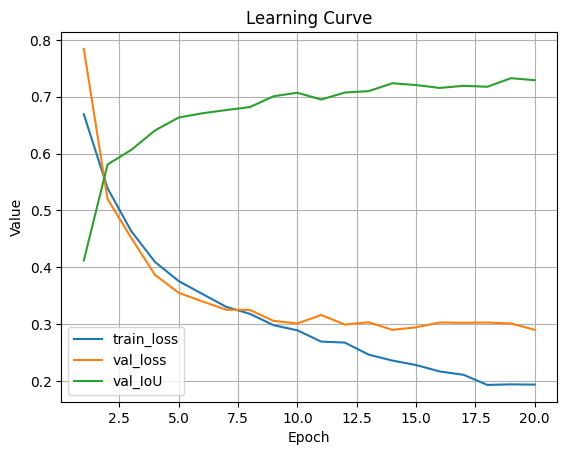

In [19]:
# ===== 학습 루프 (Training Loop) =====
# 지정한 에폭 수만큼 train → evaluate를 반복하며 손실과 IoU를 기록
from tqdm import tqdm

epochs = 20  # 전체 데이터를 반복 학습할 횟수

# 에폭별 손실 및 IoU 기록용 리스트
tr_loss_list, val_loss_list, val_iou_list = [], [], []

# tqdm: 에폭 진행 상황을 시각적 진행 바로 표시
pbar = tqdm(range(epochs), desc="Training Progress")

for t in pbar:
    # ── 학습 단계: 파라미터 업데이트 ──
    tr_loss = train(train_dataloader, model, loss_fn, optimizer, device)

    # ── 검증 단계: 성능 측정 (파라미터 변경 없음) ──
    val_loss, val_iou = evaluate(val_dataloader, model, loss_fn, device)

    # 에폭별 결과 누적 저장 (나중에 학습 곡선 그리기 위해)
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    val_iou_list.append(val_iou)

    # 진행 바에 현재 에폭의 지표 실시간 표시
    pbar.set_postfix({
        "train_loss": f"{tr_loss:.4f}",
        "val_loss":   f"{val_loss:.4f}",
        "val_IoU":    f"{val_iou:.4f}"
    })

# 학습 완료 후 손실/IoU 변화 그래프 출력
dl_learning_curve(tr_loss_list, val_loss_list, val_iou_list)

### (2) 최종 모델 평가

In [20]:
# ===== 최종 모델 평가: 클래스별 IoU 계산 =====
# 테스트셋 전체 예측 결과를 모아 클래스별 IoU와 평균 mIoU를 계산
# 클래스: 0=배경, 1=동물, 2=윤곽선

model.eval()     # 평가 모드 전환
all_preds   = [] # 전체 배치 예측값을 누적할 리스트
all_targets = [] # 전체 배치 정답 마스크를 누적할 리스트

with torch.no_grad():  # 기울기 추적 끄기 (메모리 절약)
    for images, masks in test_dataloader:
        images = images.to(device)
        masks  = masks.to(device).squeeze(1).long()  # (N, H, W) 정수형

        pred_logits = model(images)                  # (N, num_classes, H, W) 로짓
        pred_class  = torch.argmax(pred_logits, dim=1)  # 채널 중 최대값 인덱스 → 예측 클래스

        all_preds.append(pred_class.cpu())    # CPU로 이동 후 저장
        all_targets.append(masks.cpu())

# 모든 배치 결과를 하나의 텐서로 합치기
all_preds   = torch.cat(all_preds,   dim=0)  # (전체 샘플 수, H, W)
all_targets = torch.cat(all_targets, dim=0)  # (전체 샘플 수, H, W)

# 클래스별 IoU 개별 계산 및 출력
iou_list = []
for c, name in enumerate(['배경', '동물', '윤곽선']):
    pred_c   = (all_preds == c)    # 모델이 클래스 c로 예측한 픽셀
    target_c = (all_targets == c)  # 실제 클래스 c인 픽셀

    intersection = (pred_c & target_c).sum().item()  # 두 마스크의 교집합
    union        = (pred_c | target_c).sum().item()  # 두 마스크의 합집합

    iou = intersection / union if union > 0 else 1.0  # IoU 계산 (분모 0 예외 처리)
    iou_list.append(iou)
    print(f"{name} IoU: {iou:.4f}")

# 전체 클래스 평균 IoU (mIoU)
print(f"\n평균 IoU (mIoU): {sum(iou_list)/len(iou_list):.4f}")

배경 IoU: 0.8130
동물 IoU: 0.8938
윤곽선 IoU: 0.4820

평균 IoU (mIoU): 0.7296


In [21]:
# ===== 테스트셋 최종 손실 & IoU 평가 =====
# evaluate 함수로 테스트셋 전체의 평균 손실과 평균 mIoU를 한번에 계산
# 이 값이 모델의 최종 성능 지표

test_loss, test_iou = evaluate(test_dataloader, model, loss_fn, device)
print(f"Test Loss: {test_loss:.4f} | Test IoU: {test_iou:.4f}")

Test Loss: 0.2868 | Test IoU: 0.7297


### (3) 예측 결과 시각화

